In [3]:
#
# Importation des librairies
#

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import shap

from kagglehub import KaggleDatasetAdapter

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

from sklearn.calibration import CalibratedClassifierCV

In [4]:
#
# Chargement des données
#

fichier = "UCI_Credit_Card.csv"

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "uciml/default-of-credit-card-clients-dataset",
    fichier,
)

df.info()
df.head()

Using Colab cache for faster access to the 'default-of-credit-card-clients-dataset' dataset.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [5]:
#
# Nettoyage de la base de donnée
#

if 'ID' in df.columns:
    df = df.drop(columns=['ID']) # Je supprime la colonne 'ID'

df['EDUCATION'] = df['EDUCATION'].replace([0,5,6], 4) # Les catégories 0, 5 et 6 sont 'erreurs', 'catégories rares', 'non définies', je les remplace donc par la catégorie 4 (autres)
df['MARRIAGE'] = df['MARRIAGE'].replace(0, 3) # Je remplace la valeur 0 par 3 (autres), 1 = marié, 2 = célib.

In [6]:
#
# Création de nouvelles variables (features)
#

df['utilisation_credit_moy'] = (
    df[['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']]
    .mean(axis=1)
) / df['LIMIT_BAL'] # C'est la moyenne des dépenses sur les 6 derniers mois

df['utilisation_credit_max'] = (
    df[['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']]
    .max(axis=1)
) / df['LIMIT_BAL'] # C'est le montant maximum dépensé parmi les 6 derniers mois

df['ratio_paiement'] = df['PAY_AMT1'] / df['BILL_AMT1'] # C'est un ratio qui montre si le client paie correctement ou pas (1 c'est parfait)

df = df.replace([np.inf, -np.inf], np.nan).fillna(0) # Je nettoie les variables infinies en NaN puis en 0

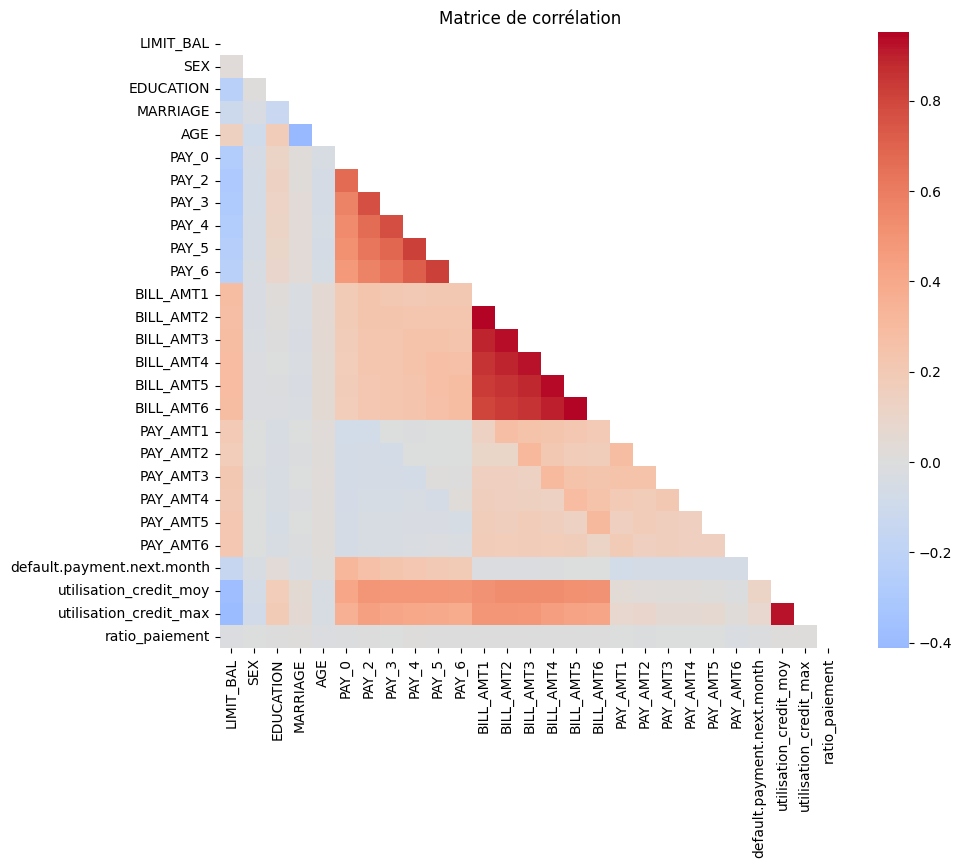

Top variables corrélées au défaut :
default.payment.next.month    1.000000
PAY_0                         0.324794
PAY_2                         0.263551
PAY_3                         0.235253
PAY_4                         0.216614
PAY_5                         0.204149
PAY_6                         0.186866
utilisation_credit_moy        0.115483
utilisation_credit_max        0.081577
EDUCATION                     0.033842
Name: default.payment.next.month, dtype: float64


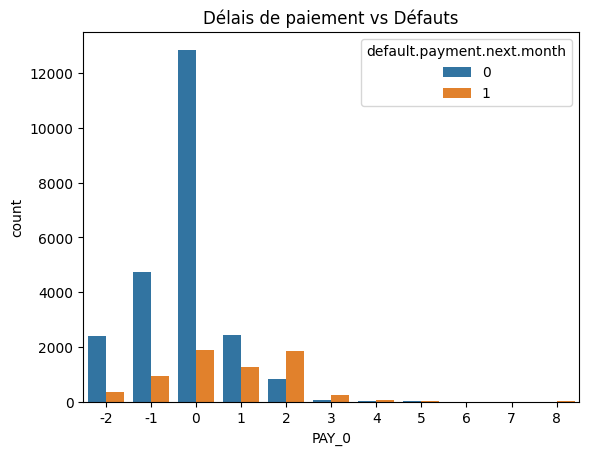

In [7]:
#
# Visualisation et analyse
#

# Matrice de corrélation
plt.figure(figsize=(10,8))

corr = df.select_dtypes(include=['number']).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0)
plt.title("Matrice de corrélation")
plt.show()

corr_target = corr['default.payment.next.month'].sort_values(ascending=False) # Je fais un classement des variables les plus corrélées. (PAY_0 = retard d'un mois)

print("Top variables corrélées au défaut :")
print(corr_target.head(10)) # Top 10


# 3. Retard de paiement d'un mois (0 = pas de défaut, 1 = défaut)
sns.countplot(x='PAY_0', hue='default.payment.next.month', data=df)
plt.title("Délais de paiement vs Défauts")
plt.show()

# (Exemple) axe des X = 2 : parmi les clients avec 2 mois de retard, x (0) n'ont pas fait défaut et x (1) on fait défaut
# -2 : pas de consommation, -1 : payé à temps, 0 : pas de retards, 1 : 1 mois de retard, etc.

In [8]:
#
# Suite
#

df['age_group'] = pd.cut(df['AGE'], bins=[20,30,40,50,60,80]) # Je transforme une variable d'age en catégorie

# Je transforme les variables de type catégorie en variable numérique
df_encoded = pd.get_dummies(
    df,
    columns=['SEX','EDUCATION','MARRIAGE'],
    drop_first=True
)

# Je sépare en deux la catégorie 'default.payment.next.month' afin d'équilibrer
df_majority = df_encoded[df_encoded['default.payment.next.month'] == 0]
df_minority = df_encoded[df_encoded['default.payment.next.month'] == 1]

nonDefautLength = len(df_majority)
DefautLength = len(df_minority)
ratioMajMin = nonDefautLength/(nonDefautLength+DefautLength)*100

print("\n- Avant équilibrage")
print("Taille catégorie clients qui ne font pas défaut :", nonDefautLength)
print("Taille catégorie clients qui font défaut :", DefautLength)

print("\nClients qui ne font pas défaut :", round(ratioMajMin, 2), "%")
print("Clients qui font défaut :", round(100-ratioMajMin, 2), "%")

print("\nOn observe un gros déséquilibre")

df_minority_upsampled = df_minority.sample(
    len(df_majority), # Je veux qui la plus petite catégorie soit de la taille de la grande désormais
    replace=True,
    random_state=42
)

df_balanced = pd.concat([df_majority, df_minority_upsampled]) # J'équilibre

counts = df_balanced['default.payment.next.month'].value_counts()

count0 = counts[0]
count1 = counts[1]

print("\n- Après équilibrage")
print("Taille catégorie clients qui ne font pas défaut :", count0)
print("Taille catégorie clients qui font défaut :", count1)

df_clean = df_balanced.select_dtypes(include=['number', 'bool']) # Je garde que les int, float et les bool pour faire tourner les modèles

X = df_clean.drop(columns=['default.payment.next.month']) # En x, je garde que les features, je supprime donc la colonne target
y = df_clean['default.payment.next.month'] # En y, j'ai la colonne target

X = X.replace([np.inf, -np.inf], np.nan).fillna(0) # Je nettoie comme avant


- Avant équilibrage
Taille catégorie clients qui ne font pas défaut : 23364
Taille catégorie clients qui font défaut : 6636

Clients qui ne font pas défaut : 77.88 %
Clients qui font défaut : 22.12 %

On observe un gros déséquilibre

- Après équilibrage
Taille catégorie clients qui ne font pas défaut : 23364
Taille catégorie clients qui font défaut : 23364


In [15]:
#
# Définition des modèles
#

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2, # 80% en train, 20% en test
    random_state=42,
    stratify=y
)

# J'ai choisi la regression logistic, le random forest, le XGBoost et le MLP
models = {
    "LogReg": Pipeline([
        ("prep", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ]), # Modèle de base en credit scoring (très interprétable avec les coef., rapide)

    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_leaf=15,
        class_weight="balanced",
        random_state=42
    ), # Permet de capturer les relations non linéaires, résiste au bruit

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        eval_metric="logloss",
        random_state=42
    ), # Modèle performant sur données tabulaires (apprend de ses erreurs)

    "MLP": Pipeline([
        ("prep", StandardScaler()),
        ("model", MLPClassifier(hidden_layer_sizes=(64,32), max_iter=300))
    ]) # Deep learning simple (capture les relations complexes)
}


LogReg
AUC: 0.7283085913774779
F1: 0.665571256435535
[[3255 1418]
 [1635 3038]]

RandomForest
AUC: 0.8786033512313017
F1: 0.7903939796370075
[[3881  792]
 [1102 3571]]

XGBoost
AUC: 0.844521452627336
F1: 0.7485157387700235
[[3760  913]
 [1332 3341]]

MLP
AUC: 0.8458398614567094
F1: 0.7804424229894563
[[3447 1226]
 [ 898 3775]]


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


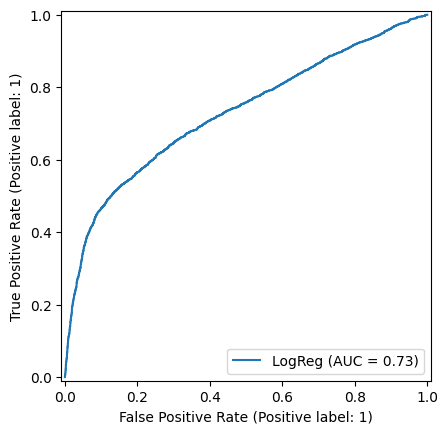

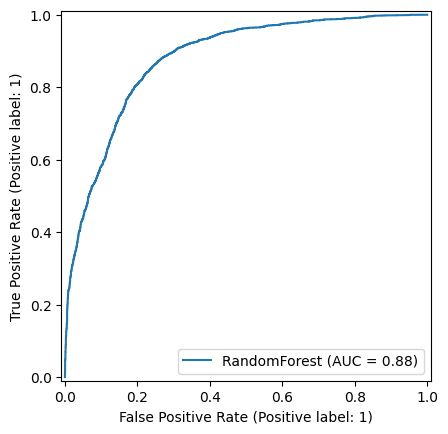

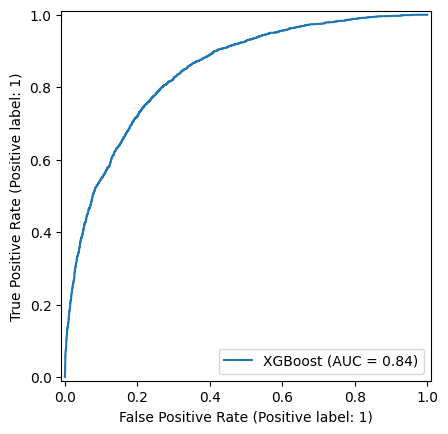

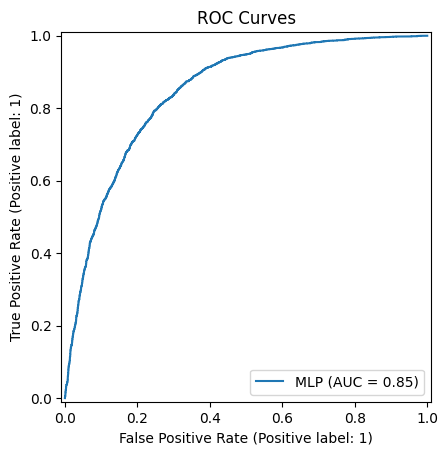

In [16]:
#
# Application des modèles
#

for name, model in models.items():
    print("\n====================")
    print(name)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print("AUC:", roc_auc_score(y_test, y_proba))
    print("F1:", f1_score(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))

    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name)

plt.title("ROC Curves")
plt.show()

# Interprétation

# AUC :
#     Capacité du modèle à classer correctement
#     1 = parfait
#     0.5 = hasard

# F1 Score :
#     Moyenne entre précision et rappel

In [17]:
#
# Vérification de l'overfitting
#

rf = models["RandomForest"]

y_train_pred = rf.predict(X_train)
y_train_proba = rf.predict_proba(X_train)[:, 1]

y_test_pred = rf.predict(X_test)
y_test_proba = rf.predict_proba(X_test)[:, 1]

print("Train AUC :", roc_auc_score(y_train, y_train_proba))
print("Test AUC :", roc_auc_score(y_test, y_test_proba))

scores = cross_val_score(rf, X, y, cv=5, scoring="roc_auc")

print("\nCross validation", scores)

# Avant de mettre 15 branches et 15 feuilles, j'avais un AUC d'environ 0,98 en train et en test
# Il y avait donc de l'overfitting

Train AUC : 0.9217932953700839
Test AUC : 0.8786033512313017

Cross validation [0.8638513  0.86245071 0.86538043 0.88535063 0.88457464]


In [18]:
#
# Calibration avec le modèle Random Forest
#


# Les probabilités que nous a donné le RF sont souvent mal calibré
calibrated_model = CalibratedClassifierCV(
    RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42
    ),
    method="isotonic", # isotonic ou sigmoid
    cv=3
)

calibrated_model.fit(X_train, y_train)

y_proba_cal = calibrated_model.predict_proba(X_test)[:,1]

print("\nAUC Calibré :", roc_auc_score(y_test, y_proba_cal))


AUC Calibré : 0.9757677235658916


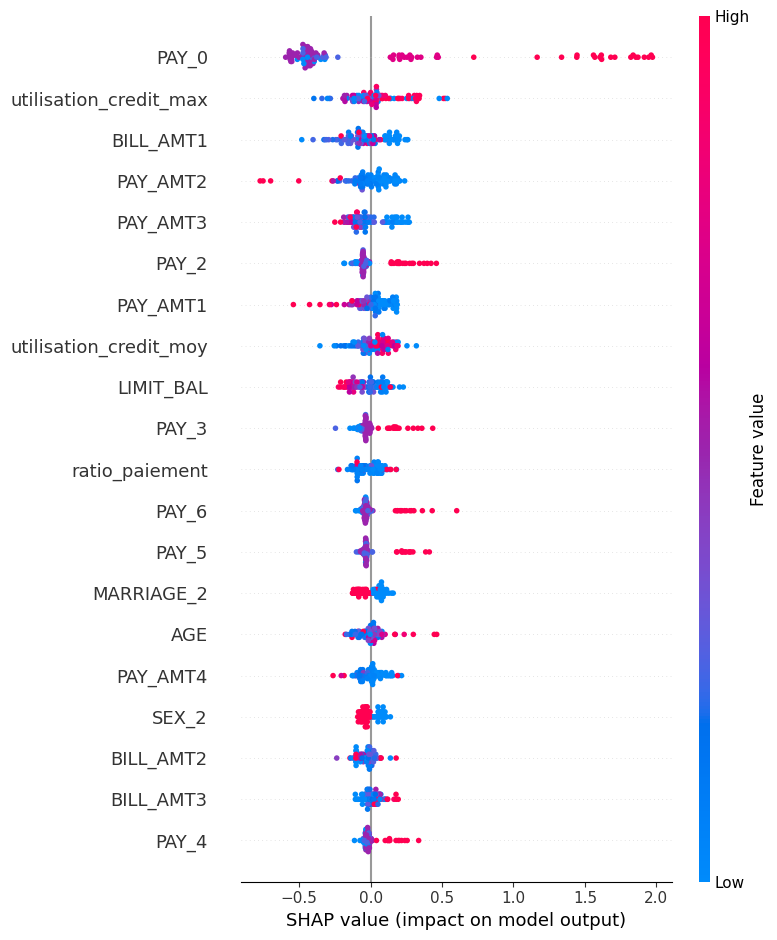

In [19]:
#
# SHAP avec le modèle XGBoost (Random Forest est trop long à exécuter)
#

xgb = models["XGBoost"]

xgb.fit(X_train, y_train)

X_sample = X_test.sample(100, random_state=42)

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample)


Top 10 des Features importance :
PAY_0                     0.187131
PAY_2                     0.084498
utilisation_credit_max    0.049435
PAY_3                     0.049362
utilisation_credit_moy    0.047777
PAY_4                     0.043816
PAY_AMT1                  0.042407
PAY_5                     0.038030
PAY_AMT2                  0.037155
BILL_AMT1                 0.036631
dtype: float64


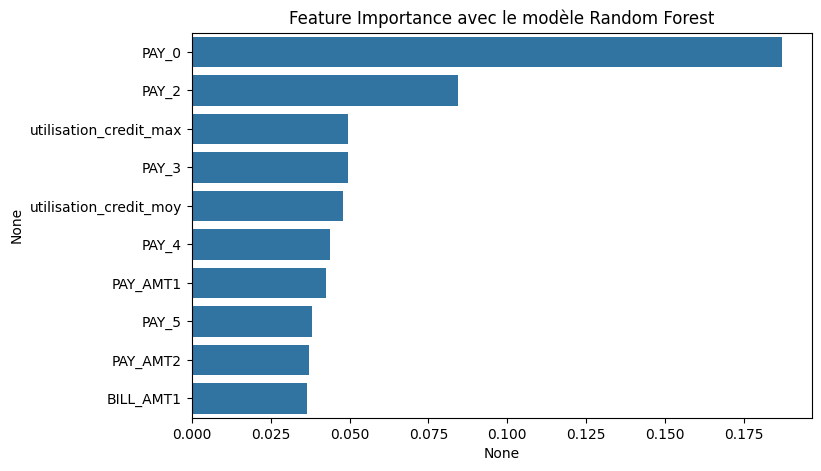

In [20]:
#
# Feature importance
#

rf = models["RandomForest"]

importances = rf.feature_importances_

feat_importance = pd.Series(importances, index=X.columns)\
    .sort_values(ascending=False)

print("\nTop 10 des Features importance :")
print(feat_importance.head(10))

plt.figure(figsize=(8,5))
sns.barplot(
    x=feat_importance.head(10),
    y=feat_importance.head(10).index
)
plt.title("Feature Importance avec le modèle Random Forest")
plt.show()